In [9]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import git
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch_geometric.data import Dataset

from scripts.parser import get_parser
from utils.data import get_dataset
from runners import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# plt.rcParams["animation.html"] = "jshtml"

Generating d-regular graph with n=20, d=3, seed=1


C:\Users\Martin\Desktop\gnn-comb-opt\venv\Lib\site-packages\torch_geometric\io\fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([Graph])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "


GNN with GCNConv on MIS | SHA: 766e73af11bc3175a2fdd971a4cb07ac0eee87d6
-----------------------------------------------------------------------
Training with random seed 1...
Epoch: 1000, Loss: -0.5016478896141052
Epoch: 2000, Loss: -2.1196367740631104
Epoch: 3000, Loss: -5.5977253913879395
Epoch: 4000, Loss: -6.843915939331055
Epoch: 5000, Loss: -7.350393295288086
Epoch: 6000, Loss: -7.609570503234863
Epoch: 7000, Loss: -7.756516456604004
Early stopping triggered due to small changes
Random seed 1 | Epochs: 7829 | Best epoch: 7829
Best loss: -7.8326, last loss: -7.8325
Calculating violations...
Independence number found by GNN is 8 with 0 violations


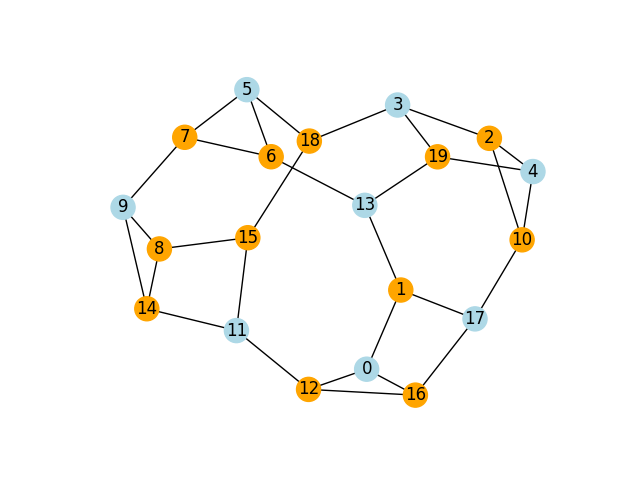

Calculating violations...
Independence number found by solver is 7 with 0 violations


In [11]:
parser = get_parser()
parsed_args = parser.parse_args(["--seed", "0"])  # "--problem_size", "20"

parsed_args.data_type = getattr(torch, parsed_args.data_type)
exp_dataset: Dataset = get_dataset(parsed_args.domain, data_size=parsed_args.data_size,
                                   problem_size=parsed_args.problem_size, node_degree=parsed_args.node_degree,
                                   graph_type=parsed_args.graph_type,
                                   dtype=parsed_args.data_type, device=parsed_args.device,
                                   save_to_file=False)

repo = git.Repo(search_parent_directories=True)
sha = repo.head.object.hexsha
parsed_args.sha = sha

setting_msg = f'{parsed_args.model_cls} with {parsed_args.gcn_cls} on {parsed_args.domain} | SHA: {sha}'
print(setting_msg)
print('-' * len(setting_msg))

best_training_loss, best_prediction, improvement_to_solver = SimpleRunner.run(
    parsed_args, exp_dataset, 1, visualize=True
)

In [8]:
SimpleRunner.postprocess(exp_dataset, best_prediction, visualize=False)

Calculating violations...
Independence number found by GNN is 8 with 0 violations
Calculating violations...
Independence number found by solver is 7 with 0 violations


[tensor(1, dtype=torch.int32)]